# Brain Stroke Prediction - Classification

## Section 1: Introduction and Dataset Overview

### Problem Statement

Stroke is a major cause of death and long-term disability worldwide. Early identification of high-risk individuals can enable timely intervention and improve patient outcomes.

This project develops a binary classification model to *predict* whether a patient is likely to suffer a stroke *(Class 1)* or not *(Class 0)* using demographic and clinical features.

The primary evaluation metric is **Recall for Class 1**, as correctly identifying stroke cases is more important than *avoiding false positives*. In a medical setting, missing a true stroke case (false negative) can have *serious consequences*.


### Dataset Description

The training dataset (`brain_stroke_data.csv`) contains 4,482 patient records with 11 columns. The unseen dataset (`brain_stroke_unseen.csv`) contains 499 records with 10 columns (the `stroke` target column is absent, as expected for held-out evaluation).

| Column | Type | Description |
|---|---|---|
| `gender` | Categorical | Patient sex: Male or Female |
| `age` | Numeric | Patient age in years |
| `hypertension` | Binary (0/1) | Whether the patient has hypertension |
| `heart_disease` | Binary (0/1) | Whether the patient has heart disease |
| `ever_married` | Categorical | Marital status: Yes or No |
| `work_type` | Categorical | Employment category: Private, Self-employed, Govt_job, children |
| `Residence_type` | Categorical | Urban or Rural residence |
| `avg_glucose_level` | Numeric | Average blood glucose level (mg/dL) |
| `bmi` | Numeric | Body Mass Index |
| `smoking_status` | Categorical | Smoking history: never smoked, formerly smoked, smokes, Unknown |
| `stroke` | Binary (0/1) | **Target variable** -> 1 = stroke occurred, 0 = no stroke |

The `smoking_status` value **"Unknown"** indicates that the patient's smoking history *was not recorded*; it is a legitimate data category and is **not treated as a missing value**. Similarly, `work_type = "children"` is a valid category representing minors and is retained as-is.

In [99]:
# Import all required libraries

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

from imblearn.over_sampling import SMOTE

# Consistent plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [100]:
# Load the training and unseen datasets using relative paths

df = pd.read_csv('brain_stroke_data.csv')
df_unseen = pd.read_csv('brain_stroke_unseen.csv')

print(f"Training dataset shape: {df.shape}")
print(f"Unseen dataset shape: {df_unseen.shape}")

Training dataset shape: (4482, 11)
Unseen dataset shape: (499, 10)


In [101]:
# training data inspection (few rows)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,0
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0


In [102]:
# unseen data inspection (few rows)
df_unseen.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Female,49.0,0,0,Yes,Private,Rural,56.11,28.7,smokes
1,Male,75.0,0,0,Yes,Private,Rural,75.47,24.5,formerly smoked
2,Female,71.0,0,0,Yes,Private,Rural,100.61,19.2,Unknown
3,Female,12.0,0,0,No,children,Rural,85.97,35.7,Unknown
4,Male,63.0,0,0,Yes,Private,Rural,104.79,24.1,Unknown


In [103]:
# column data types
df.dtypes

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [104]:
# statistics summary
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4482.000000,4482.000000,4482.000000,4482.000000,4482.000000,4482.000000
mean,43.446693,0.098394,0.054663,105.761430,28.466064,0.049755
std,22.592327,0.297879,0.227347,44.943627,6.764658,0.217462
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,26.000000,0.000000,0.000000,77.192500,23.600000,0.000000
50%,45.000000,0.000000,0.000000,91.680000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.637500,32.575000,0.000000
max,82.000000,1.000000,1.000000,267.760000,48.900000,1.000000


## Section 2: Exploratory Data Analysis (EDA)

The EDA phase is used to assess data quality and explore relationships between features and stroke occurrence. Key findings and any resulting preprocessing decisions are anottated alongside each visualisation.


In [105]:
# check for missing values (both datasets)

print("Missing values - training data:")
print(df.isnull().sum())
print()
print("Missing values - unseen data:")
print(df_unseen.isnull().sum())

Missing values - training data:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Missing values - unseen data:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
dtype: int64


**Finding:** There are *no* missing values in either dataset. The `smoking_status = "Unknown"` entries are not missing values - they represent patients whose smoking history was not recorded, and are kept as a valid category.

In [106]:
# check for duplicate rows
print(f"duplicate rows in training data: {df.duplicated().sum()}")
print(f"duplicate rows in unseen data: {df_unseen.duplicated().sum()}")

duplicate rows in training data: 0
duplicate rows in unseen data: 0


**Finding:** No duplicate rows were found.

In [107]:
# unique values per column

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values  ->  {df[col].unique()[:8]}")

gender: 2 unique values  ->  ['Female' 'Male']
age: 104 unique values  ->  [46. 65. 70. 47. 31. 53. 52.  5.]
hypertension: 2 unique values  ->  [0 1]
heart_disease: 2 unique values  ->  [0 1]
ever_married: 2 unique values  ->  ['Yes' 'No']
work_type: 4 unique values  ->  ['Private' 'Self-employed' 'Govt_job' 'children']
Residence_type: 2 unique values  ->  ['Urban' 'Rural']
avg_glucose_level: 3580 unique values  ->  [ 78.79 248.24 118.81 111.84  65.7  113.21  67.5   80.81]
bmi: 338 unique values  ->  [42.4 27.  26.  33.7 30.4 28.6 27.7 39. ]
smoking_status: 4 unique values  ->  ['smokes' 'Unknown' 'formerly smoked' 'never smoked']
stroke: 2 unique values  ->  [0 1]


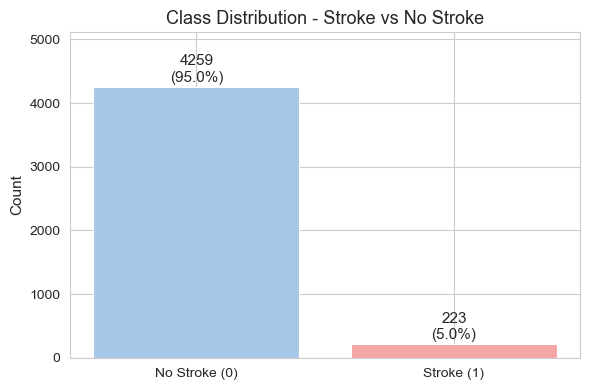

In [108]:
# class distribution - imbalance visualisation check
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['stroke'].value_counts()

bars = ax.bar(
    ['No Stroke (0)', 'Stroke (1)'],
    counts.values,
    color=['#A7C7E7', '#F4A6A6'],  # pastel blue, pastel red
    edgecolor='white',
    linewidth=0.8
)

for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{count}\n({count/len(df)*100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.set_title('Class Distribution - Stroke vs No Stroke')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)

plt.tight_layout()
plt.show()

**Class Imbalance:** The dataset is highly imbalanced, with approximately **95%** of patients in the *no-stroke* class and only **5%** in the *stroke* class. Therefore, a model could achieve high accuracy by predicting no stroke for every patient while missing all stroke cases. To address this, accuracy is not used as the main evaluation metric, and SMOTE oversampling is applied during training (see Section 4).


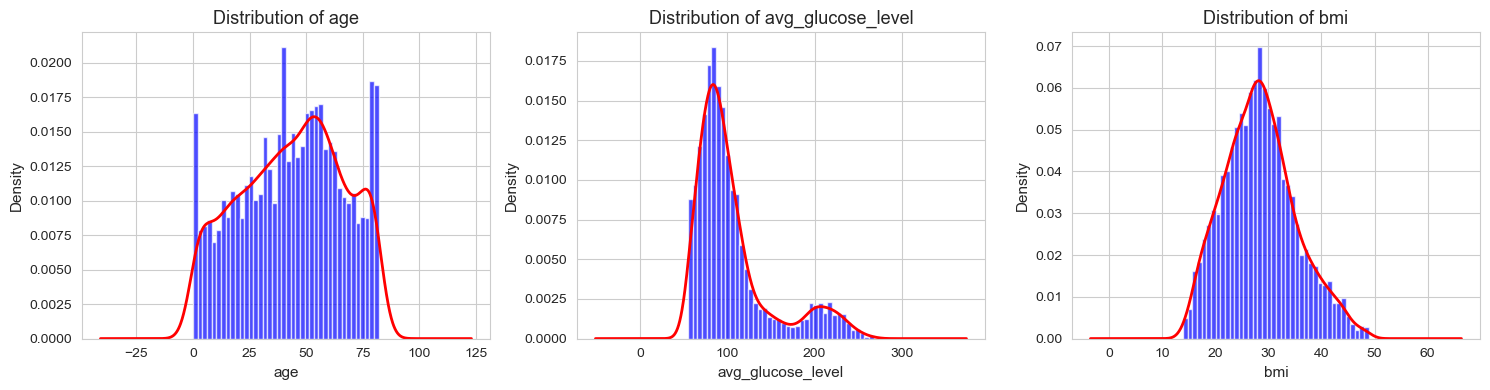

Skewness of age: -0.144
Skewness of avg_glucose_level: 1.594
Skewness of bmi: 0.371


In [109]:
# Histograms and KDE plots for numeric features
numeric_features = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_features):
    ax.hist(df[col], bins=40, color='blue', edgecolor='white',
            alpha=0.7, density=True)
    df[col].plot(kind='kde', ax=ax, color='red', linewidth=2)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

# Print skewness for each feature
for col in numeric_features:
    print(f"Skewness of {col}: {df[col].skew():.3f}")

### Numeric Feature Distributions

- **Age** is spread across a wide range of values, from young children to older adults, with a slightly higher concentration of older patients.
- **Average Glucose Level** is right-skewed, with most patients having values below 120 mg/dL and a smaller group showing much higher glucose levels. These higher values may be associated with conditions such as diabetes.
- **BMI** is also slightly right-skewed, with most patients falling within the overweight range and fewer patients having very high BMI values.

Both **average glucose level** and **BMI** show some imbalance, which is common in healthcare datasets. To ensure all numeric features are on a comparable scale, **StandardScaler** will be applied during preprocessing, particularly for models such as Logistic Regression.

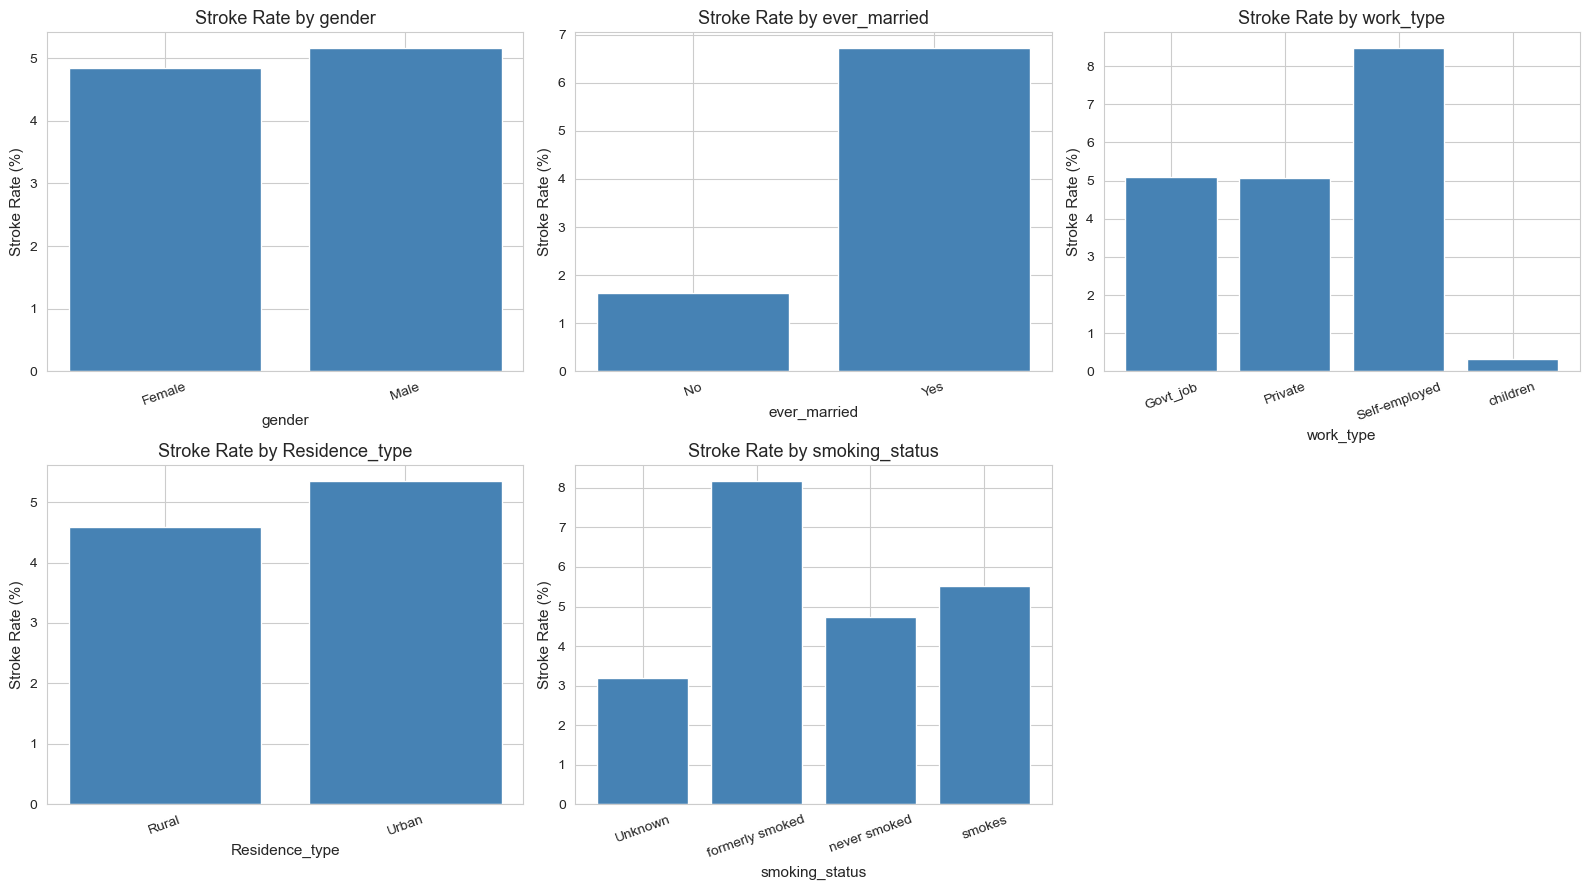

In [110]:
# stroke rate by each categorical feature
categorical_features = ['gender', 'ever_married', 'work_type','Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    stroke_rate = df.groupby(col)['stroke'].mean().reset_index()
    stroke_rate.columns = [col, 'stroke_rate']
    axes[i].bar(stroke_rate[col], stroke_rate['stroke_rate'] * 100,
                color='steelblue', edgecolor='white')
    axes[i].set_title(f'Stroke Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Stroke Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

### Categorical Feature Analysis

- **Gender:** Stroke rates are fairly similar across males and females, suggesting that gender on its own may not be a strong predictor of stroke risk.
- **Ever Married:** Patients who have been married appear more likely to have experienced a stroke. This is likely related to age, as older individuals are both more likely to have been married and more likely to suffer a stroke.
- **Work Type:** Stroke rates tend to be higher among self-employed individuals and those working in government roles. As expected, patients in the *children* category have very few stroke cases.
- **Residence Type:** Urban and rural patients show very similar stroke rates, indicating that place of residence may have limited predictive value.
- **Smoking Status:** Former and current smokers show slightly higher stroke rates than never-smokers. The **Unknown** category also displays a meaningful stroke rate, so it will be retained as a separate category rather than being imputed.

Overall, **ever_married**, **work_type**, and **smoking_status** appear to show some relationship with stroke occurrence and may provide useful information to the predictive models.

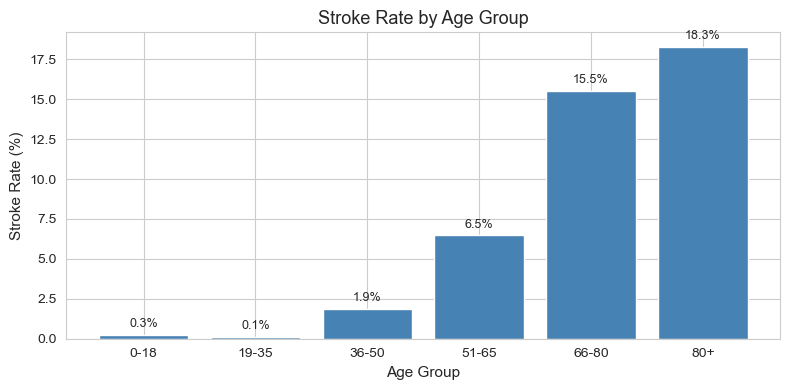

In [111]:
# stroke rate by age group
bins = [0, 18, 35, 50, 65, 80, 100]
labels = ['0-18', '19-35', '36-50', '51-65', '66-80', '80+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

stroke_by_age = df.groupby('age_group', observed=True)['stroke'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(stroke_by_age.index, stroke_by_age.values,
       color='steelblue', edgecolor='white')
ax.set_title('Stroke Rate by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Stroke Rate (%)')
for i, v in enumerate(stroke_by_age.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Drop the temporary column
df.drop(columns=['age_group'], inplace=True)

### Age Group Analysis

Stroke rates increase noticeably with age. Patients aged 51–65 show a higher incidence of stroke than younger age groups, with rates rising further among those aged 66–80 and 80+. In contrast, stroke cases are very rare among patients under 35.

This pattern suggests that **age is one of the strongest predictors of stroke risk** in the dataset. For modelling purposes, age will be retained as a continuous numeric feature and scaled during preprocessing.

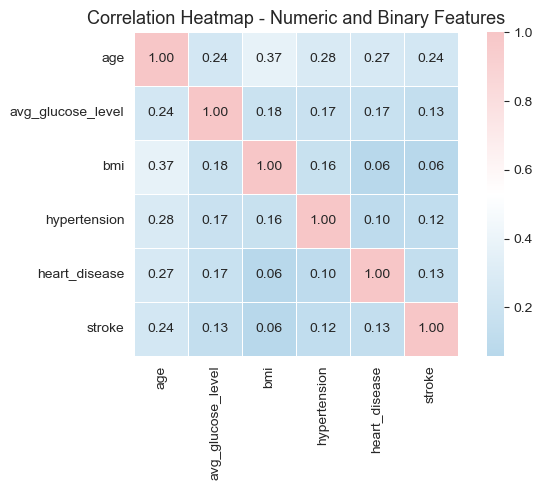

In [112]:
# Create correlation matrix
corr_cols = ['age', 'avg_glucose_level', 'bmi',
             'hypertension', 'heart_disease', 'stroke']

corr_matrix = df[corr_cols].corr()

# Custom pastel colour map
pastel_cmap = LinearSegmentedColormap.from_list(
    'pastel_corr',
    ['#B8D8EB', '#FFFFFF', '#F7C6C7']
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap=pastel_cmap,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Heatmap - Numeric and Binary Features')
plt.tight_layout()
plt.show()

### Correlation Analysis

Age has the strongest relationship with stroke among the numeric features, followed by hypertension and heart disease. Average glucose level and BMI also show positive relationships with stroke, although these are weaker.

There are no strong correlations between the predictor variables themselves, suggesting that *multicollinearity* is not a concern and all features can be retained for modelling.

Overall, the relatively low correlation values are not surprising, as stroke is influenced by multiple factors rather than any single characteristic.

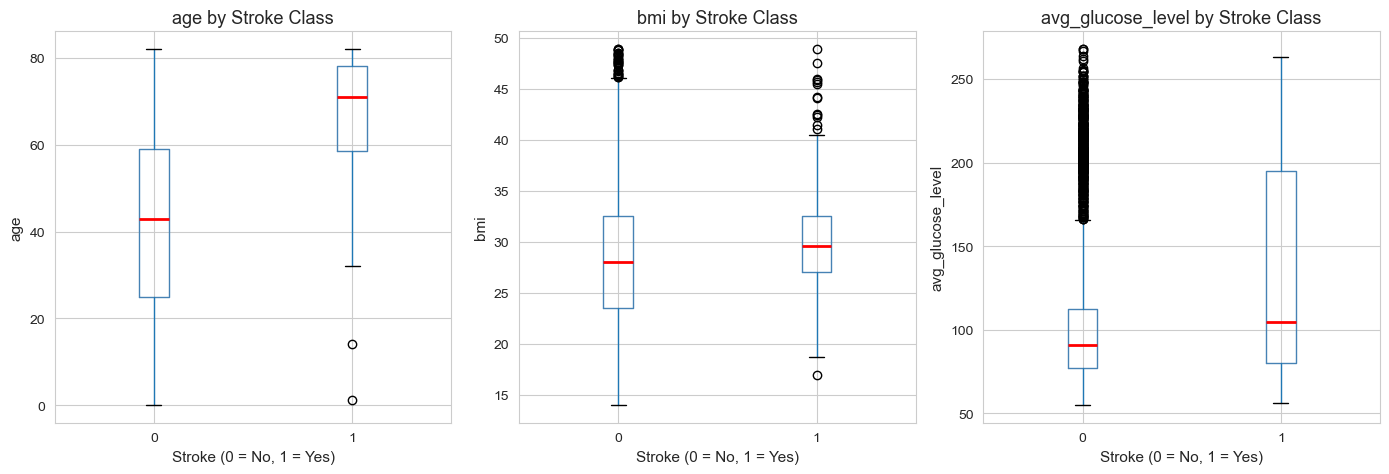

In [113]:
# boxplots of numeric features vs stroke class
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
features = ['age', 'bmi', 'avg_glucose_level']

for ax, feat in zip(axes, features):
    df.boxplot(column=feat, by='stroke', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{feat} by Stroke Class')
    ax.set_xlabel('Stroke (0 = No, 1 = Yes)')
    ax.set_ylabel(feat)

plt.suptitle('')
plt.tight_layout()
plt.show()

### Boxplot Analysis

- **Age:** Patients who experienced a stroke tend to be noticeably older than those who did not. The difference in age distributions is clear, suggesting that age is one of the strongest predictors of stroke in the dataset.
- **BMI:** There is considerable overlap between the two groups, although stroke patients generally have slightly higher BMI values. This suggests that BMI may contribute to stroke risk but is unlikely to be a strong predictor on its own.
- **Average Glucose Level:** Patients who experienced a stroke tend to have higher glucose levels and greater variation in their readings. This supports the idea that elevated glucose levels may be associated with an increased risk of stroke.

Overall, **age appears to provide the clearest separation between stroke and non-stroke patients**, while BMI and average glucose level show weaker but still potentially useful relationships.

## Section 3: Data Preprocessing

### Encoding Strategy

Different types of features require different preprocessing approaches.

- **Binary categorical features** (`gender`, `ever_married`, `Residence_type`) contain only two categories, so they are encoded as 0 and 1 using an Ordinal Encoder. Keeping the dataset compact without losing any information.

- **Multi-class categorical features** (`work_type`, `smoking_status`) contain several distinct categories with no natural order. These features are transformed using *One-Hot Encoding*, creating a separate binary column for each category. This avoids introducing artificial relationships between categories.

- **Numeric features** (`age`, `avg_glucose_level`, `bmi`) are standardised using StandardScaler. This places all numeric variables on a similar scale, which is particularly important for Logistic Regression and can also help improve model training efficiency.

### Pipeline Design

A `ColumnTransformer` is used to apply all preprocessing steps in a single pipeline. This ensures that the same transformations are applied consistently across the training, test, and unseen datasets. It also helps to prevent data leakage by calculating scaling and encoding parameters using only the training data.

In [114]:
# separate features and target variable
X = df.drop(columns=['stroke'])
y = df['stroke']

# define feature groups by encoding strategy
binary_cats = ['gender', 'ever_married', 'Residence_type']
multi_cats = ['work_type', 'smoking_status']
numeric = ['age', 'avg_glucose_level', 'bmi']

print("Binary categoricals (OrdinalEncoder):", binary_cats)
print("Multi-class categoricals (OneHotEncoder):", multi_cats)
print("Numeric features (StandardScaler):", numeric)
print("Binary pass-through (already encoded): ['hypertension', 'heart_disease']")

Binary categoricals (OrdinalEncoder): ['gender', 'ever_married', 'Residence_type']
Multi-class categoricals (OneHotEncoder): ['work_type', 'smoking_status']
Numeric features (StandardScaler): ['age', 'avg_glucose_level', 'bmi']
Binary pass-through (already encoded): ['hypertension', 'heart_disease']


In [115]:
# build the ColumnTransformer preprocessing pipeline
# OrdinalEncoder for binary categoricals, OneHotEncoder for multi-class,
# StandardScaler for numeric; hypertension and heart_disease pass through unchanged
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric),
    ('bin_cat', OrdinalEncoder(), binary_cats),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False), multi_cats),
], remainder='passthrough')

print("preprocessor built successfully!!!")
print(preprocessor)

preprocessor built successfully!!!
ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['age', 'avg_glucose_level', 'bmi']),
                                ('bin_cat', OrdinalEncoder(),
                                 ['gender', 'ever_married', 'Residence_type']),
                                ('ohe',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['work_type', 'smoking_status'])])


### Notes on Preprocessing Decisions

- The **"Unknown"** category in `smoking_status` is retained rather than imputed.
- The **"children"** category in `work_type` is kept as a valid category, as it represents genuine observations within the dataset and may help capture age-related patterns.
- The `hypertension` and `heart_disease` features are already stored as binary values (0/1), so no additional preprocessing is required.

## Section 4: Train/Test Split

The dataset is divided into training and test sets using an 80/20 split. This provides enough data for model training while still reserving a meaningful portion of the data for evaluation. Given the relatively small number of stroke cases, using 80% of the data for training helps ensure that the model has sufficient examples of the minority class to learn from.

Stratified sampling (`stratify=y`) is used to maintain the original class distribution in both the training and test sets. This ensures that each split contains a similar proportion of stroke and non-stroke cases, resulting in a more reliable evaluation of model performance.

In [116]:
# 80/20 stratified split - preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")
print(f"\ntraining class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\ntest class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set size: 3585 rows
Test set size: 897 rows

training class distribution:
stroke
0    0.95
1    0.05
Name: proportion, dtype: float64

test class distribution:
stroke
0    0.95
1    0.05
Name: proportion, dtype: float64


## Section 5: Handling Class Imbalance

### Why Class Imbalance Matters?

The dataset is highly imbalanced, with around *95%* of patients belonging to the no-stroke class. In this situation, a model could achieve high accuracy simply by predicting no stroke for every patient, while failing to identify any actual stroke cases. Since detecting stroke cases is the main objective of this project, addressing the class imbalance is essential.

### Approach: SMOTE

To help the model learn from the minority class, SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data. Rather than duplicating existing stroke cases, SMOTE generates new synthetic examples based on similar observations, providing the model with a more balanced set of training data.

Importantly, SMOTE is applied **only after the train/test split** and only to the training data. This prevents information from the test set influencing the training process and ensures that model performance is evaluated fairly.

### Alternative Approaches

Other methods were considered, including class weighting and random undersampling. However, SMOTE was selected because it *increases the representation of stroke cases without removing potentially useful data from the majority class*, making it a suitable choice for this medical prediction task.

In [117]:
# applying preprocessing to training data; fit here, transform both sets
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"preprocessed training shape: {X_train_preprocessed.shape}")
print(f"preprocessed test shape: {X_test_preprocessed.shape}")

preprocessed training shape: (3585, 14)
preprocessed test shape: (897, 14)


In [118]:
# class distribution BEFORE SMOTE
print("Class distribution BEFORE SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

# applying SMOTE to the preprocessed training data (ONLY)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_preprocessed, y_train)

# class distribution AFTER SMOTE
print("\nClass distribution AFTER SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} ({cnt/len(y_train_smote)*100:.1f}%)")

Class distribution BEFORE SMOTE:
Class 0: 3407 (95.0%)
Class 1: 178 (5.0%)

Class distribution AFTER SMOTE:
Class 0: 3407 (50.0%)
Class 1: 3407 (50.0%)


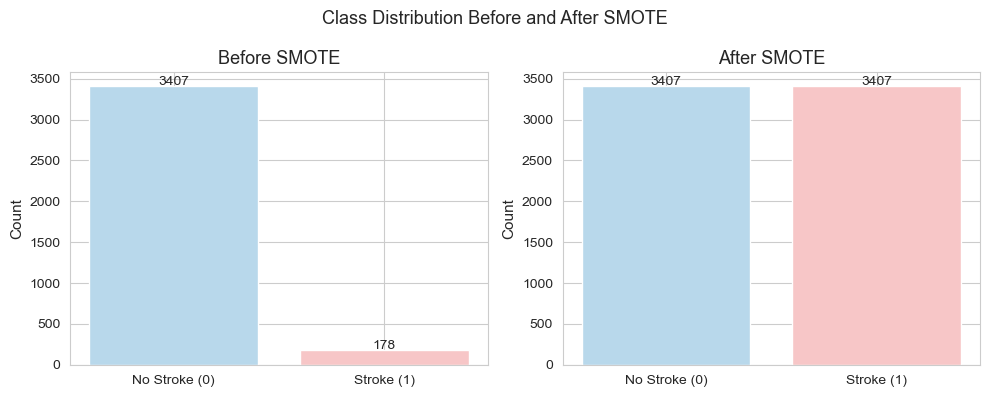

In [119]:
# visualisation of class balance BEFORE and ATER SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_smote).value_counts().sort_index()

colors = ['#B8D8EB', '#F7C6C7']  # pastel blue, pastel red

axes[0].bar(
    ['No Stroke (0)', 'Stroke (1)'],
    before.values,
    color=colors,
    edgecolor='white'
)
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

for i, v in enumerate(before.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

axes[1].bar(
    ['No Stroke (0)', 'Stroke (1)'],
    after.values,
    color=colors,
    edgecolor='white'
)
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

for i, v in enumerate(after.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=10)

plt.suptitle('Class Distribution Before and After SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

### SMOTE Results

SMOTE successfully balanced the training data by increasing the number of stroke cases to match the number of non-stroke cases. The test set was left unchanged, allowing model performance to be evaluated on data that reflects the original class distribution.

## Section 6: Model Training and Evaluation

Four classification models are trained using the SMOTE-balanced training data and evaluated on the original test set. A fixed `random_state=42` is used throughout to ensure that results can be reproduced.

For each model, performance is assessed using a classification report, a confusion matrix, and the key evaluation metrics of Accuracy, Precision, Recall, and F1 Score. Particular attention is given to **Recall for the stroke class**, as correctly identifying stroke cases is the primary objective of this project.

In [120]:
# utility function: evaluate a trained model and display all metrics
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"{model_name}")
    print("\nclassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))

    # confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: No Stroke', 'Pred: Stroke'],
                yticklabels=['True: No Stroke', 'True: Stroke'], ax=ax)
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    # metrics for class 1 (the positive/minority class)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"accuracy: {acc:.4f}")
    print(f"precision (class 1): {prec:.4f}")
    print(f"recall (class 1): {rec:.4f}")
    print(f"F1 Score (class 1): {f1:.4f}")

    return {'Model': model_name, 'Accuracy': acc,'Precision (Class 1)': prec, 'Recall (Class 1)': rec,'F1 (Class 1)': f1}

### 6.1 Logistic Regression

**How it works:** Logistic Regression estimates the probability of a patient experiencing a stroke based on the input features. These probabilities are then used to classify patients as either stroke or no-stroke cases.

**Strengths:** Logistic Regression is simple, fast, and easy to interpret. It performs well when features are properly scaled and provides a useful baseline for comparison with more complex models.

**Limitations:** as it assumes a linear relationship between the features and the target variable, it may struggle to capture more complex patterns that are often present in healthcare data.

Logistic Regression

classification Report:


              precision    recall  f1-score   support

   No Stroke       0.98      0.72      0.83       852
      Stroke       0.13      0.78      0.22        45

    accuracy                           0.72       897
   macro avg       0.56      0.75      0.53       897
weighted avg       0.94      0.72      0.80       897



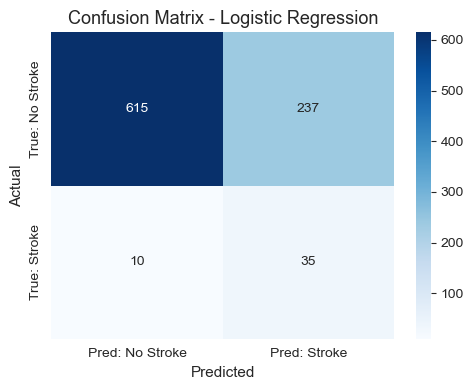

accuracy: 0.7246
precision (class 1): 0.1287
recall (class 1): 0.7778
F1 Score (class 1): 0.2208


In [121]:
# train logistic regression on SMOTE-resampled training data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

# evaluate on the original (non-SMOTE) test set
results_lr = evaluate_model(lr, X_test_preprocessed, y_test, 'Logistic Regression')

**Interpretation:** Logistic Regression was able to identify a reasonable number of stroke cases after SMOTE was applied to the training data. As the main goal of this project is to detect patients at risk of stroke, recall is particularly important, as a higher recall means fewer stroke cases are missed.

### 6.2 Decision Tree Classifier

**How it works:** A Decision Tree makes predictions by repeatedly splitting the data into smaller groups based on the features that best separate stroke and non-stroke cases. The resulting structure can be visualised as a series of decision rules.

**Strengths:** Decision Trees can capture complex, non-linear relationships in the data and do not require feature scaling. They are also relatively easy to interpret and explain.

**Limitations:** Decision Trees can become overly complex and fit too closely to the training data, which may reduce their ability to generalise to new data. To help prevent this, the tree depth is optimised using cross-validation.

In [122]:
# tune max_depth for the Decision Tree 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
depth_scores = {}

for depth in range(3, 11):
    dt_cv = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt_cv, X_train_smote, y_train_smote, cv=cv, scoring='f1')
    depth_scores[depth] = scores.mean()
    print(f"max_depth={depth}: mean F1 = {scores.mean():.4f}")

best_depth = max(depth_scores, key=depth_scores.get)
print(f"\nselected max_depth: {best_depth} (F1={depth_scores[best_depth]:.4f})")

max_depth=3: mean F1 = 0.8140
max_depth=4: mean F1 = 0.8301
max_depth=5: mean F1 = 0.8374
max_depth=6: mean F1 = 0.8481
max_depth=7: mean F1 = 0.8603
max_depth=8: mean F1 = 0.8762
max_depth=9: mean F1 = 0.8869
max_depth=10: mean F1 = 0.8984

selected max_depth: 10 (F1=0.8984)


Decision Tree

classification Report:
              precision    recall  f1-score   support

   No Stroke       0.95      0.86      0.90       852
      Stroke       0.07      0.20      0.10        45

    accuracy                           0.82       897
   macro avg       0.51      0.53      0.50       897
weighted avg       0.91      0.82      0.86       897



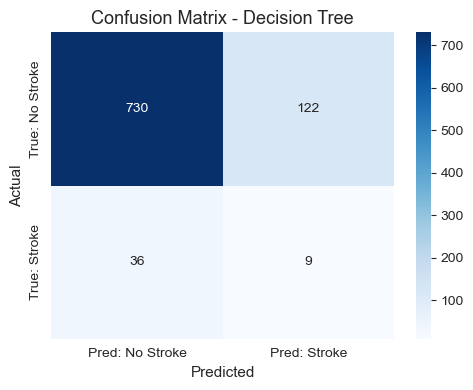

accuracy: 0.8239
precision (class 1): 0.0687
recall (class 1): 0.2000
F1 Score (class 1): 0.1023


In [123]:
# train Decision Tree with the cross-validated best max_depth
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train_smote, y_train_smote)

# evaluate on the original test set
results_dt = evaluate_model(dt, X_test_preprocessed, y_test, 'Decision Tree')

**Interpretation:** Limiting the depth of the tree helps reduce overfitting and improves its ability to generalise to new data. The models performance can then be compared with the other classifiers, in particular in terms of recall and F1 score, to determine whether its simplicity and interpretability come at the cost of predictive performance.

### 6.3 Random Forest Classifier

**How it works:** Random Forest combines the predictions of multiple Decision Trees, with each tree trained on a different sample of the training data. The final prediction is based on the majority vote across all trees.

**Strengths:** Random Forest can capture complex patterns in the data while reducing the risk of overfitting. It is generally robust, performs well on a wide range of datasets, and often achieves stronger predictive performance than a single Decision Tree.

**Limitations:** Although typically more accurate than an individual tree, the model is harder to interpret and requires more computational resources.

Random Forest

classification Report:
              precision    recall  f1-score   support

   No Stroke       0.95      0.96      0.96       852
      Stroke       0.06      0.04      0.05        45

    accuracy                           0.92       897
   macro avg       0.51      0.50      0.50       897
weighted avg       0.91      0.92      0.91       897



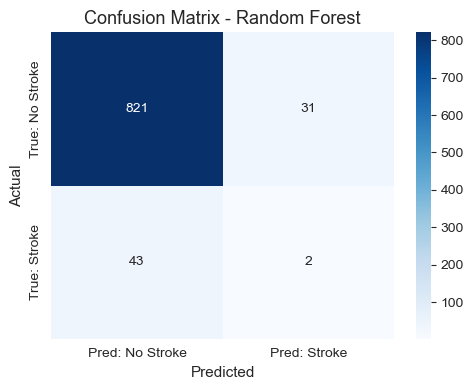

accuracy: 0.9175
precision (class 1): 0.0606
recall (class 1): 0.0444
F1 Score (class 1): 0.0513


In [124]:
# train Random Forest on SMOTE-resampled data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)

# evaluate on the original test set
results_rf = evaluate_model(rf, X_test_preprocessed, y_test, 'Random Forest')

**Interpretation:** Random Forest often provides a good balance between identifying stroke cases and avoiding false positives. By combining the predictions of multiple trees, it can produce more stable and reliable results than a single Decision Tree. Comparing its recall and F1 score with the other models helps determine whether the ensemble approach leads to improved performance.

### 6.4 Gradient Boosting Classifier

**How it works:** Gradient Boosting builds a series of small Decision Trees, with each new tree focusing on the mistakes made by the previous ones. By gradually improving on earlier predictions, the model aims to achieve stronger overall performance.

**Why this model was included?** Gradient Boosting is widely recognised for its strong performance on structured datasets and is often effective at identifying more complex patterns in the data. It provides a useful comparison with Random Forest by using a different ensemble learning approach.

**Strengths:** Gradient Boosting often achieves high predictive accuracy and can capture complex relationships between features.

**Limitations:** The model takes longer to train than the other classifiers and can be more sensitive to parameter settings. It is also more difficult to interpret than simpler models such as Logistic Regression or a single Decision Tree.

Gradient Boosting

classification Report:
              precision    recall  f1-score   support

   No Stroke       0.96      0.90      0.93       852
      Stroke       0.12      0.27      0.17        45

    accuracy                           0.87       897
   macro avg       0.54      0.58      0.55       897
weighted avg       0.92      0.87      0.89       897



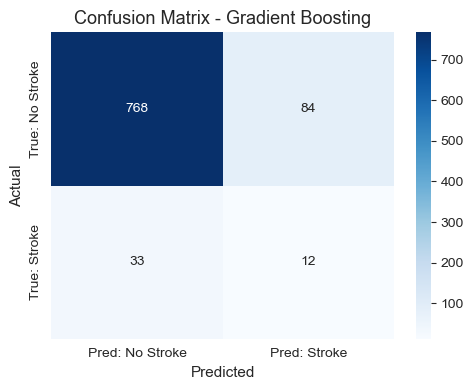

accuracy: 0.8696
precision (class 1): 0.1250
recall (class 1): 0.2667
F1 Score (class 1): 0.1702


In [125]:
# train gradient boosting on SMOTE-resampled data
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_smote, y_train_smote)

# evaluate on the original test set
results_gb = evaluate_model(gb, X_test_preprocessed, y_test, 'Gradient Boosting')

**Interpretation:** Gradient Boosting is often able to identify complex patterns in the data, which may lead to strong performance when detecting stroke cases. Comparing its recall and F1 score with those of Random Forest helps determine which ensemble model is better suited to this prediction task.

## Section 7: Model Comparison

The performance of all four models is compared using the same evaluation metrics. In particular attention is given to **Recall for the stroke class**, as the main goal of this project is to **identify as many stroke cases as possible**.

In a healthcare setting, missing a patient who is at risk of stroke can have serious consequences. While a **false positive** may result in *additional testing or monitoring*, a **false negative** could mean that a patient does not receive the intervention they need. For this reason, recall is considered the most important metric when selecting the best model.

In [126]:
# compile results into a comparison DataFrame
results_all = [results_lr, results_dt, results_rf, results_gb]
comparison_df = pd.DataFrame(results_all).set_index('Model')
print(comparison_df.round(4))

                     Accuracy  Precision (Class 1)  Recall (Class 1)  \
Model                                                                  
Logistic Regression    0.7246               0.1287            0.7778   
Decision Tree          0.8239               0.0687            0.2000   
Random Forest          0.9175               0.0606            0.0444   
Gradient Boosting      0.8696               0.1250            0.2667   

                     F1 (Class 1)  
Model                              
Logistic Regression        0.2208  
Decision Tree              0.1023  
Random Forest              0.0513  
Gradient Boosting          0.1702  


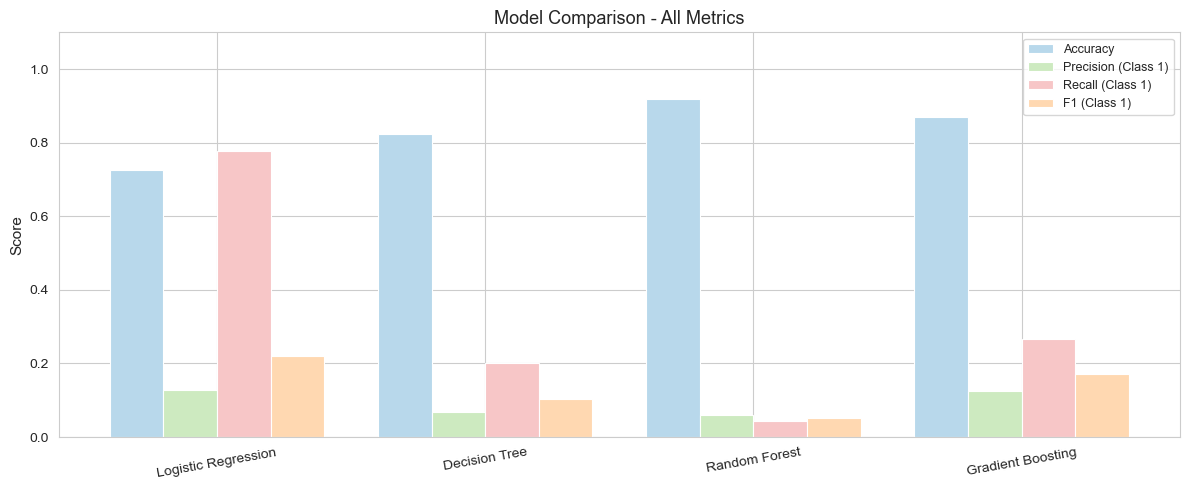

In [127]:
# grouped bar chart comparing all models across all metrics
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(comparison_df))
width = 0.2

metrics = ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1 (Class 1)']

colors = [
    '#B8D8EB',  # pastel blue
    '#CDEAC0',  # pastel green
    '#F7C6C7',  # pastel red
    '#FFD8B1'   # pastel orange
]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(
        x + i * width,
        comparison_df[metric],
        width,
        label=metric,
        color=color,
        edgecolor='white',
        linewidth=0.8
    )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df.index, rotation=10)

ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Metrics')
ax.set_ylim(0, 1.1)

ax.legend(
    loc='upper right',
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

In [128]:
# select best model by Recall (Class 1) - primary clinical metric
best_model_name = comparison_df['Recall (Class 1)'].idxmax()
print(f"Best model by Recall (Class 1): {best_model_name}")
print()
print(comparison_df.loc[best_model_name].round(4))

Best model by Recall (Class 1): Logistic Regression

Accuracy               0.7246
Precision (Class 1)    0.1287
Recall (Class 1)       0.7778
F1 (Class 1)           0.2208
Name: Logistic Regression, dtype: float64


**Model Selection:** The best-performing model is selected primarily based on its **Recall for the stroke class**, as the main objective is to identify as many stroke cases as possible. The **F1 score** is also considered, as it provides a balance between recall and precision and helps ensure that the model is not simply predicting stroke for every patient. The chosen model is then taken forward for hyperparameter tuning.

## Section 8: Hyperparameter Tuning

After selecting the best-performing model, GridSearchCV is used to identify the combination of hyperparameters that produces the strongest results. A 5-fold Stratified Cross-Validation approach is applied to ensure that each fold maintains a similar class distribution. The search is optimised using the **F1 score for the stroke class**, as this metric balances the need to identify stroke cases while limiting false positives.

In [129]:
# hyperparameter grids for each candidate best model
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l2']
    },
    'Decision Tree': {
        'max_depth': list(range(3, 11)),
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }
}

# base model instances for GridSearchCV
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# run the GridSearchCV on the best model selected
print(f"Running GridSearchCV for: {best_model_name}")
grid_search = GridSearchCV(
    estimator=base_models[best_model_name],
    param_grid=param_grids[best_model_name],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_smote, y_train_smote)

print(f"\nbest parameters found:")
print(grid_search.best_params_)
print(f"\nbest cross-validated F1 (class 1): {grid_search.best_score_:.4f}")

Running GridSearchCV for: Logistic Regression

best parameters found:
{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

best cross-validated F1 (class 1): 0.8157


Logistic Regression (Tuned)

classification Report:
              precision    recall  f1-score   support

   No Stroke       0.98      0.72      0.83       852
      Stroke       0.13      0.78      0.22        45

    accuracy                           0.72       897
   macro avg       0.56      0.75      0.52       897
weighted avg       0.94      0.72      0.80       897



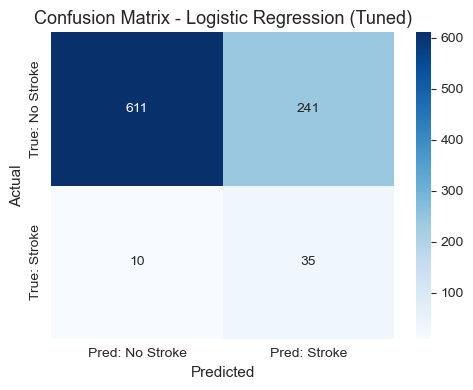

accuracy: 0.7202
precision (class 1): 0.1268
recall (class 1): 0.7778
F1 Score (class 1): 0.2181


In [130]:
# evaluate the tuned model on the test set
best_model_tuned = grid_search.best_estimator_
results_tuned = evaluate_model(best_model_tuned, X_test_preprocessed, y_test, f'{best_model_name} (Tuned)')

In [131]:
# Compare baseline vs tuned performance side by side
print(f"Comparison: {best_model_name} - Baseline vs Tuned")
baseline = comparison_df.loc[best_model_name]
tuned_series = pd.Series({
    'Accuracy': results_tuned['Accuracy'],
    'Precision (Class 1)': results_tuned['Precision (Class 1)'],
    'Recall (Class 1)': results_tuned['Recall (Class 1)'],
    'F1 (Class 1)': results_tuned['F1 (Class 1)']
})

cmp = pd.DataFrame({'Baseline': baseline, 'Tuned': tuned_series})
print(cmp.round(4))

Comparison: Logistic Regression - Baseline vs Tuned
                     Baseline   Tuned
Accuracy               0.7246  0.7202
Precision (Class 1)    0.1287  0.1268
Recall (Class 1)       0.7778  0.7778
F1 (Class 1)           0.2208  0.2181


**Tuning Outcome:** GridSearchCV identifies the combination of hyperparameters that performs best during cross-validation. The resulting model is then used for the final evaluation and predictions, allowing its performance to be compared with the original baseline model.

## Section 9: Predictions on Unseen Data

To ensure a fair evaluation, the same preprocessing steps used during training are applied to the unseen dataset without being refitted. Meaning that all scaling and encoding transformations are based only on information learnt from the training data, helping to prevent data leakage and maintain consistency.

The tuned model is then used to generate predictions for all 499 records in the unseen dataset.

In [132]:
# apply the already-fitted preprocessor to the unseen dataset (transform only, no refit)
X_unseen_preprocessed = preprocessor.transform(df_unseen)
print(f"unseen data preprocessed shape: {X_unseen_preprocessed.shape}")

unseen data preprocessed shape: (499, 14)


In [133]:
# generate predictions using the tuned best model
unseen_predictions = best_model_tuned.predict(X_unseen_preprocessed)

# display first 10 predictions
print("first 10 predictions:")
print(unseen_predictions[:10])

# predicted class distribution
unique, counts = np.unique(unseen_predictions, return_counts=True)
print("\npredicted class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"class {cls}: {cnt} ({cnt/len(unseen_predictions)*100:.1f}%)")

first 10 predictions:
[0 1 1 0 1 1 1 0 0 1]

predicted class distribution:
class 0: 339 (67.9%)
class 1: 160 (32.1%)


In [134]:
# save predictions to CSV with column name 'Predictions'
predictions_df = pd.DataFrame({'Predictions': unseen_predictions})
predictions_df.to_csv('brain_stroke_predictions.csv', index=False)
print("predictions saved to: brain_stroke_predictions.csv")
predictions_df.head(10)

predictions saved to: brain_stroke_predictions.csv


,Predictions
0,0
1,1
2,1
3,0
4,1
5,1
6,1
7,0
8,0
9,1
